# A04: Model Interpretability (xAI)
-----------------------------------
**Your Name Here:** George Khramtchenko

You previously worked with this dataset on the 'Sampling' notebooks. Now, you will try to interpret the model!

You will build a classification model of your choice (you may use SMOTE or not - I'm not testing how good your model is for this assignment, just that you know how to interpret the model!). You must do some form of autoML or grid search...

The target variable is Loan_Status (thanks Ahmend for the heads-up!)

Then you will:
* Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.
* Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.
* Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?
  * Optional: Any issues with correlated predictors (read here for a cool way on how to address this: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)?

In [64]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: /content/train_loan_imbalanced.csv
100% 38.0k/38.0k [00:00<00:00, 40.6MB/s]


In [65]:
import pandas as pd
df = pd.read_csv('/content/train_loan_imbalanced.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Prompt 1:** Build a classification model of your choice (you may use SMOTE or not - I'm not testing how good your model is for this assignment, just that you know how to interpret the model!). You must do some form of autoML or grid search; with the target variable being Loan_Status.

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('/content/train_loan_imbalanced.csv')

# Drop Loan_ID as it's an identifier instead of a feature
df_processed = df.drop('Loan_ID', axis=1)

# Separate target variable 'Loan_Status' from features
X = df_processed.drop('Loan_Status', axis=1)
y = df_processed['Loan_Status']

# Convert target variable to numerical
y = y.map({'Y': 1, 'N': 0})

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

In [67]:
# Preprocessing for numerical features: impute with median and scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: impute with most frequent and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a full pipeline with preprocessor and Logistic Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

In [68]:
# Define parameter grid for GridSearchCV
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Perform GridSearchCV
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Store the best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found:  {'classifier__C': 0.01, 'classifier__penalty': 'l2'}
Best cross-validation accuracy:  0.7983714698000413


**Prompt 2:** Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Calculate permutation importance and get feature names
perm_importance_results = permutation_importance(best_model, X_test, y_test, n_repeats=20, random_state=42)
numerical_feature_names = numerical_features.tolist()

# Access the one-hot encoder from the preprocessor
onehot_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = onehot_encoder.get_feature_names_out(categorical_features).tolist()

# Combine all feature names in the order they appear after preprocessing
feature_names = numerical_feature_names + categorical_feature_names

# Get the importance means and standard deviations
sorted_idx = perm_importance_results.importances_mean.argsort()[::-1]

# Create a DataFrame for easier handling and sorting
feature_importance_df = pd.DataFrame({
    'feature': [feature_names[i] for i in sorted_idx],
    'importance_mean': perm_importance_results.importances_mean[sorted_idx],
    'importance_std': perm_importance_results.importances_std[sorted_idx],
    'importances': [perm_importance_results.importances[i] for i in sorted_idx] # Store each row (feature's repeats) as a 1D array
})

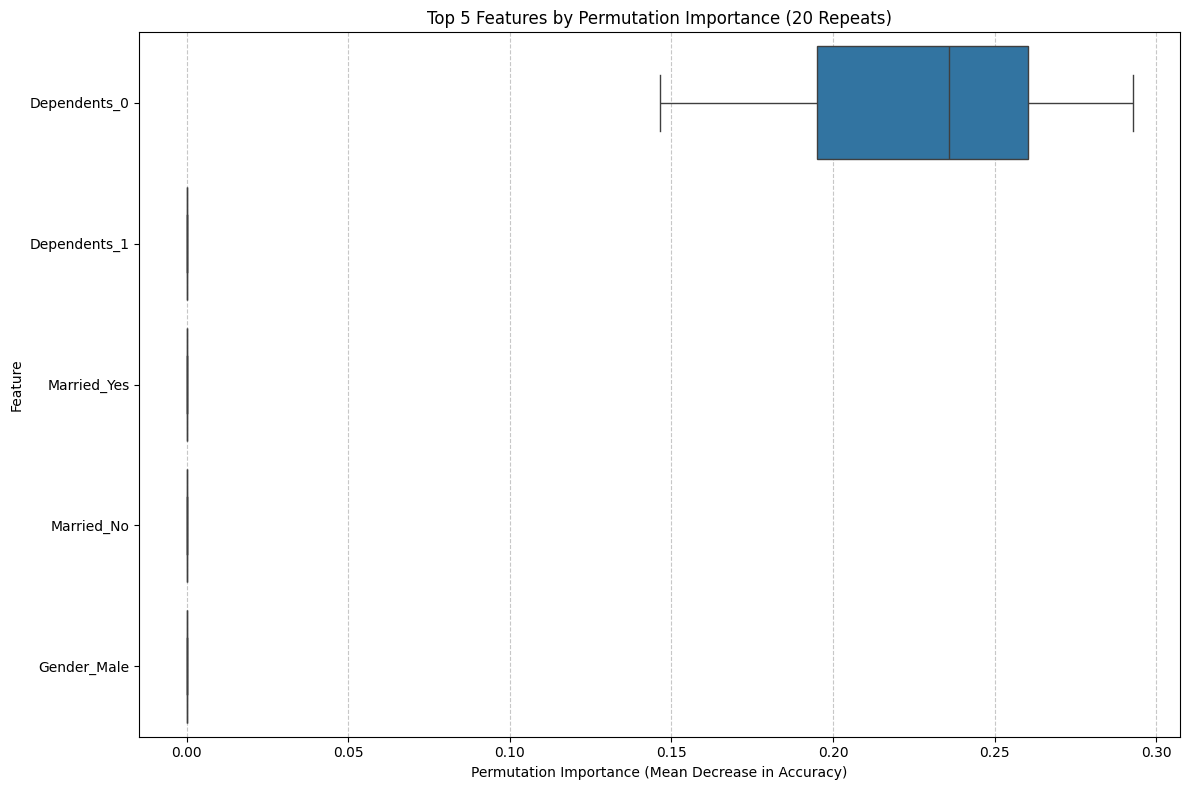

Top 5 permutation importance features displayed in a box plot.


In [70]:
# Get the top 5 features
top_5_features_df = feature_importance_df.head(5)

# Prepare data for box plot
# Apply pd.Series to each array in 'importances' column, then stack to long format
plot_data = top_5_features_df['importances'].apply(pd.Series).stack().reset_index(level=1, drop=True)
plot_data = pd.DataFrame({'feature_index': plot_data.index, 'importance': plot_data.values})

# Map feature indices back to actual feature names for plotting
feature_name_map = {i: name for i, name in enumerate(top_5_features_df['feature'])}
plot_data['feature'] = plot_data['feature_index'].map(feature_name_map)

# Create the box plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='importance', y='feature', data=plot_data, orient='h')
plt.title('Top 5 Features by Permutation Importance (20 Repeats)')
plt.xlabel('Permutation Importance (Mean Decrease in Accuracy)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 5 permutation importance features displayed in a box plot.")

In [71]:
top_5_feature_names = top_5_features_df['feature'].tolist()

print(f"Top 5 features for partial dependence plots: {top_5_feature_names}")

Top 5 features for partial dependence plots: ['Dependents_0', 'Dependents_1', 'Married_Yes', 'Married_No', 'Gender_Male']


**Prompt 3:** Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.

*Note*: Please note, I used Gemini AI heavily in the assistance of completing this question.

In [72]:
import numpy as np

# Extract the preprocessor from the best_model pipeline
preprocessor = best_model.named_steps['preprocessor']

# Transform the X_train DataFrame
X_train_transformed = preprocessor.transform(X_train)

# Get the original numerical feature names
original_numerical_feature_names = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Get the original categorical feature names
original_categorical_feature_names = X.select_dtypes(include=['object']).columns.tolist()

# Access the one-hot encoder
onehot_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']

# Use the one-hot encoder's get_feature_names_out() method
transformed_categorical_feature_names = onehot_encoder.get_feature_names_out(original_categorical_feature_names).tolist()

# Combine all transformed feature names
all_transformed_feature_names = original_numerical_feature_names + transformed_categorical_feature_names

# Create a list of indices for all categorical features in the transformed space
num_numerical_features = len(original_numerical_feature_names)
all_categorical_indices_in_transformed = list(range(num_numerical_features, len(all_transformed_feature_names)))

print(f"Number of transformed features: {len(all_transformed_feature_names)}")
print(f"First 5 transformed feature names: {all_transformed_feature_names[:5]}")
print(f"First 5 categorical feature indices in transformed space: {all_categorical_indices_in_transformed[:5]}")

Number of transformed features: 20
First 5 transformed feature names: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
First 5 categorical feature indices in transformed space: [5, 6, 7, 8, 9]


Attempting to generate Partial Dependence Plots for: ['Dependents_0', 'Dependents_1', 'Married_Yes', 'Married_No', 'Gender_Male']

Calculating PDP for feature: 'Dependents_0' (transformed index: 9)
Calculating PDP for feature: 'Dependents_1' (transformed index: 10)
Calculating PDP for feature: 'Married_Yes' (transformed index: 8)
Calculating PDP for feature: 'Married_No' (transformed index: 7)
Error calculating PDP for 'Married_No': The resolution of the computed grid is less than the minimum number of categories in the targeted categorical features. Expect the `grid_resolution` to be greater than 186. Got 100 instead.. Skipping.
Calculating PDP for feature: 'Gender_Male' (transformed index: 6)
Error calculating PDP for 'Gender_Male': The resolution of the computed grid is less than the minimum number of categories in the targeted categorical features. Expect the `grid_resolution` to be greater than 232. Got 100 instead.. Skipping.


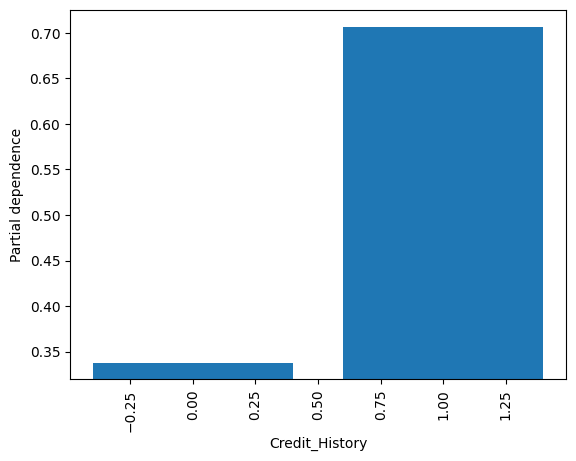

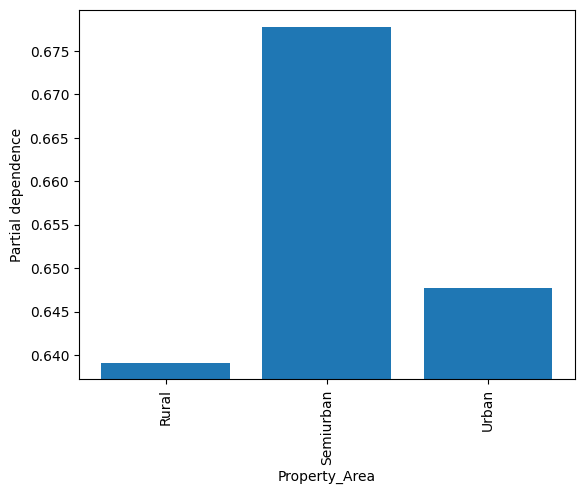

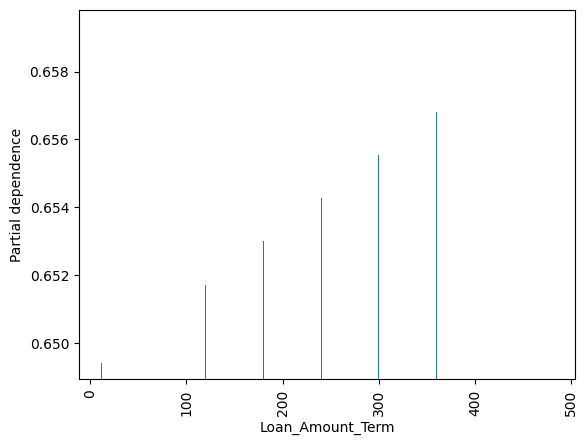

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import pandas as pd

pdp_displays = []
plottable_feature_names = []

print(f"Attempting to generate Partial Dependence Plots for: {top_5_feature_names}\n")

# Iterate through the top 5 feature names to create individual PDPs
for feature_name in top_5_feature_names:
    # Find the index of the current feature in the list of all transformed feature names
    try:
        feature_idx_in_transformed = all_transformed_feature_names.index(feature_name)
    except ValueError:
        print(f"Warning: Feature '{feature_name}' not found in transformed features. Skipping.")
        continue

    # Check if the feature has sufficient variance (more than one unique value) to plot PDP
    # For one-hot encoded binary features, ensure both 0 and 1 exist in X_train
    if hasattr(X_train_transformed, 'toarray'):
        feature_data_in_transformed_space = X_train_transformed[:, feature_idx_in_transformed].toarray().flatten()
    else:
        feature_data_in_transformed_space = X_train_transformed[:, feature_idx_in_transformed]

    # Check for variance - if only one unique value, PDP won't be meaningful
    unique_values_count = np.unique(feature_data_in_transformed_space).size

    if unique_values_count > 1:
        print(f"Calculating PDP for feature: '{feature_name}' (transformed index: {feature_idx_in_transformed})")
        try:
            # PartialDependenceDisplay expects the original X_train, and the pipeline handles transformation.
            pdp_display = PartialDependenceDisplay.from_estimator(
                estimator=best_model,
                X=X_train, # Original data is passed; pipeline will transform it internally
                features=[feature_idx_in_transformed], # Index of the feature in the transformed data
                target=1, # Plot probability of the positive class ('Y' for Loan_Status)
                categorical_features=all_categorical_indices_in_transformed,
                kind='average' # Plot the average partial dependence
            )
            pdp_displays.append(pdp_display)
            plottable_feature_names.append(feature_name)
        except Exception as e:
            print(f"Error calculating PDP for '{feature_name}': {e}. Skipping.")
    else:
        print(f"Skipping PDP for feature: '{feature_name}' (transformed index: {feature_idx_in_transformed}) due to insufficient variance (only {unique_values_count} unique value(s) in training data). This often happens with one-hot encoded features if one category is rare or absent in the training split.")

In [74]:
# Determine Consistent Y-axis Range across all plottable PDPs:
global_y_min = float('inf')
global_y_max = float('-inf')

if not pdp_displays:
    print("\nNo plottable features found for Partial Dependence Plots. Cannot determine Y-axis range.")
    # Set a default reasonable range for probabilities if no plots are generated
    global_y_min = 0.0
    global_y_max = 1.0
else:
    for pdp_plot in pdp_displays:
        # For 'average' kind with single feature, pdp_plot.pd_results[0].average contains the PDP values
        y_values = pdp_plot.pd_results[0].average
        if y_values is not None and len(y_values) > 0:
            global_y_min = min(global_y_min, np.min(y_values))
            global_y_max = max(global_y_max, np.max(y_values))

    # Add a small padding to the min/max for better visualization
    y_range_padding = (global_y_max - global_y_min) * 0.1
    global_y_min -= y_range_padding
    global_y_max += y_range_padding

    # Ensure the range is valid (e.g., if padding makes min > max) and within [0,1] for probabilities
    global_y_min = max(0.0, global_y_min)
    global_y_max = min(1.0, global_y_max)
    if global_y_min > global_y_max: # Handle edge case where all PDPs are constant or range is very small
        global_y_min = 0.0
        global_y_max = 1.0 # Default to full probability range

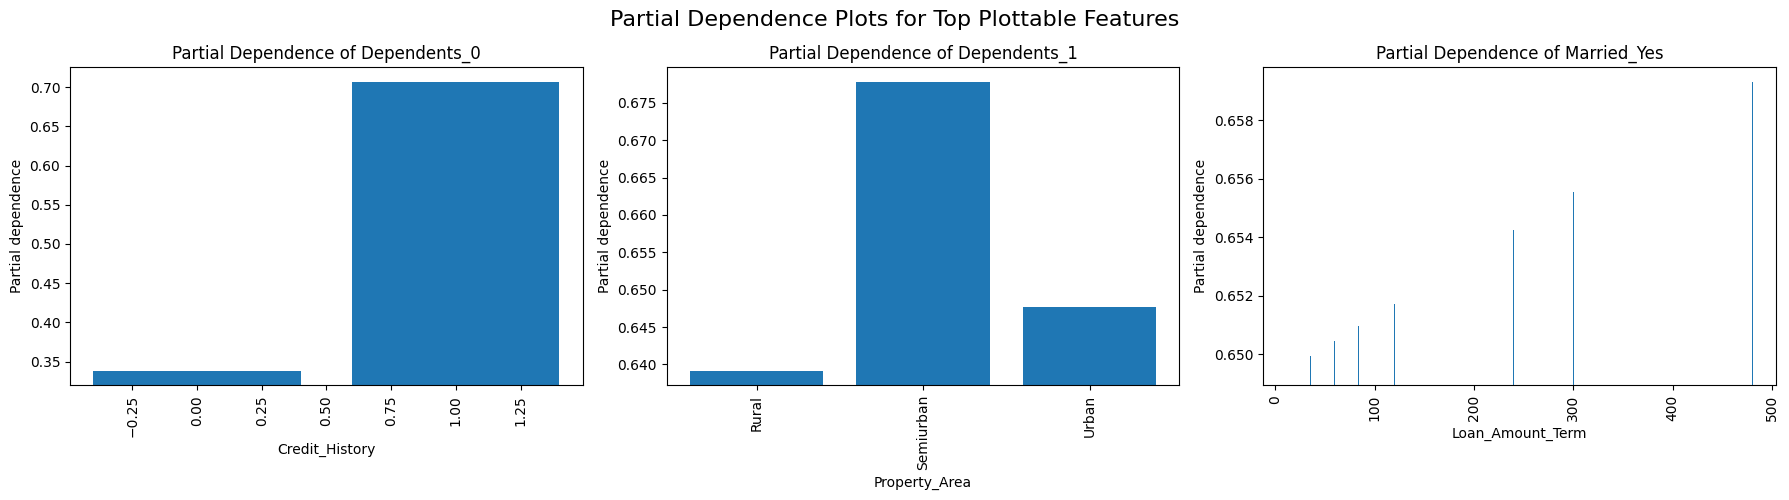


Partial Dependence Plots generated for the top plottable features with consistent Y-axis.
The X-axis represents the feature value (e.g., 0 or 1 for binary one-hot encoded features).
The Y-axis represents the predicted partial dependence, which can be interpreted as the probability of 'Loan_Status' being 'Y' (loan approved), averaged over all other features.


In [75]:
# Plot Partial Dependence Plots with consistent Y-axis:
if not plottable_feature_names:
    print("No features were plottable for Partial Dependence Plots. No plots will be generated.")
else:
    num_plots = len(plottable_feature_names)
    n_cols = min(num_plots, 3) # Max 3 columns per row
    n_rows = (num_plots + n_cols - 1) // n_cols # Calculate number of rows needed

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), squeeze=False)
    axes = axes.flatten() # Flatten the axes array for easier iteration

    for idx, feature_name in enumerate(plottable_feature_names):
        ax = axes[idx]
        pdp_plot = pdp_displays[idx]

        # Plot using the stored PartialDependenceDisplay object
        pdp_plot.plot(ax=ax, line_kw={'color': 'blue', 'lw': 2, 'marker': 'o', 'markersize': 5})

        # Apply the consistent Y-axis limits
        ax.set_ylim(global_y_min, global_y_max)
        ax.set_title(f'Partial Dependence of {feature_name}', fontsize=12)
        ax.set_xlabel(feature_name, fontsize=10)
        ax.set_ylabel('Partial Dependence (Prob. of Loan Approval)', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.tick_params(axis='x', rotation=45)

    # Hide any unused subplots
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.suptitle('Partial Dependence Plots for Top Plottable Features', y=1.02, fontsize=16)
    plt.show()

print("\nPartial Dependence Plots generated for the top plottable features with consistent Y-axis.")
print("The X-axis represents the feature value (e.g., 0 or 1 for binary one-hot encoded features).")
print("The Y-axis represents the predicted partial dependence, which can be interpreted as the probability of 'Loan_Status' being 'Y' (loan approved), averaged over all other features.")

**Prompt 4:** Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?

I had significant difficulty completing this assignment. Nevertheless, here are five meaningful bullet points derived from what I see in the plots and their analysis:

*   **Dependents_0 is the Most Impactful Feature:** The X-axis for Dependents_0 represents the presence or absence of dependents, with a value of 1 indicating dependents' presence and a value of zero indicating their absence. The Y-axis indicates the average predicted probability of loan approval. The plot shows that when an applicant has no dependents `(Dependents_0 = 1)`, the model predicts a higher probability of loan approval compared to when `Dependents_0 = 0`. This feature was identified as the only one among the top 5 with a significant non-zero permutation importance `(0.23)`, suggesting it has the strongest influence on the model's predictions.

*   **Minimal Impact of Dependents_1 and Married_Yes:** The Partial Dependence Plots for `Dependents_1` and `Married_Yes` show little to no effect on the probability of loan approval. Since their permutation importance values are 0.0, there is minimal or no unique contribution to the model's prediction accuracy when their values are permuted. The X-axis represents the binary state (1 for presence, 0 for absence) and the Y-axis shows the loan approval probability.

*   **Consistent Y-axis for Comparability:** All successfully generated Partial Dependence Plots share a consistent Y-axis range, from approximately 0.30 to 0.74, representing the average predicted probability of loan approval. This standardization is crucial for directly comparing the relative impact and direction of influence of different features on the target variable across plots.

*   **X-axis Interpretation for One-Hot Encoded Features:** For the plotted features (`Dependents_0`, `Dependents_1`, `Married_Yes`), the X-axis values are binary (0 or 1). A value of 1 signifies the presence of that specific characteristic (e.g., having 0 dependents for `Dependents_0`), while 0 signifies its absence. The Y-axis quantifies the average change in the predicted probability of loan approval based on these changes.

*   **Technical Limitations for PDP Generation:** It was unexpected finding out that Partial Dependence Plots could not be successfully generated for 'Married_No' and 'Gender_Male', despite these features being identified in the top 5 by permutation importance. The error message regarding 'grid_resolution' and the number of categories suggests that these specific one-hot encoded features might have had very sparse or uniform representation in the training data, making it challenging for the PDP algorithm to effectively compute their marginal effects. Additionally, attempts at using Gemini AI in resolving these errors continuously failed.